In [14]:
import pandas as pd

data = pd.DataFrame({
    "tenure": [2, 5, 10, 24, 36, 3, 18, 30, 6, 48, 12, 4, 60, 8, 20],
    "MonthlyCharges": [80, 75, 65, 50, 45, 90, 60, 40, 85, 35, 70, 95, 30, 88, 55],
    "Contract": [
        "Month-to-month", "Month-to-month", "Month-to-month",
        "One year", "Two year", "Month-to-month",
        "One year", "Two year", "Month-to-month",
        "Two year", "One year", "Month-to-month",
        "Two year", "Month-to-month", "One year"
    ],
    "InternetService": [
        "Fiber", "DSL", "Fiber", "DSL", "DSL",
        "Fiber", "Fiber", "DSL", "Fiber", "DSL",
        "Fiber", "Fiber", "DSL", "Fiber", "DSL"
    ],
    "TechSupport": [
        "No", "No", "Yes", "Yes", "Yes",
        "No", "Yes", "Yes", "No", "Yes",
        "Yes", "No", "Yes", "No", "Yes"
    ],
    "Churn": [
        "Yes", "Yes", "No", "No", "No",
        "Yes", "No", "No", "Yes", "No",
        "No", "Yes", "No", "Yes", "No"
    ]
})

data

,tenure,MonthlyCharges,Contract,InternetService,TechSupport,Churn
0,2,80,Month-to-month,Fiber,No,Yes
1,5,75,Month-to-month,DSL,No,Yes
2,10,65,Month-to-month,Fiber,Yes,No
3,24,50,One year,DSL,Yes,No
4,36,45,Two year,DSL,Yes,No
5,3,90,Month-to-month,Fiber,No,Yes
6,18,60,One year,Fiber,Yes,No
7,30,40,Two year,DSL,Yes,No
8,6,85,Month-to-month,Fiber,No,Yes
9,48,35,Two year,DSL,Yes,No


In [15]:
data.head()

,tenure,MonthlyCharges,Contract,InternetService,TechSupport,Churn
0,2,80,Month-to-month,Fiber,No,Yes
1,5,75,Month-to-month,DSL,No,Yes
2,10,65,Month-to-month,Fiber,Yes,No
3,24,50,One year,DSL,Yes,No
4,36,45,Two year,DSL,Yes,No


In [16]:
data.shape

(15, 6)

In [17]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   tenure           15 non-null     int64
 1   MonthlyCharges   15 non-null     int64
 2   Contract         15 non-null     str  
 3   InternetService  15 non-null     str  
 4   TechSupport      15 non-null     str  
 5   Churn            15 non-null     str  
dtypes: int64(2), str(4)
memory usage: 1.1 KB


In [18]:
data.describe()

,tenure,MonthlyCharges
count,15.000000,15.000000
mean,19.066667,64.200000
std,17.616821,21.203773
min,2.000000,30.000000
25%,5.500000,47.500000
50%,12.000000,65.000000
75%,27.000000,82.500000
max,60.000000,95.000000


In [19]:
data.isnull().sum()

tenure             0
MonthlyCharges     0
Contract           0
InternetService    0
TechSupport        0
Churn              0
dtype: int64

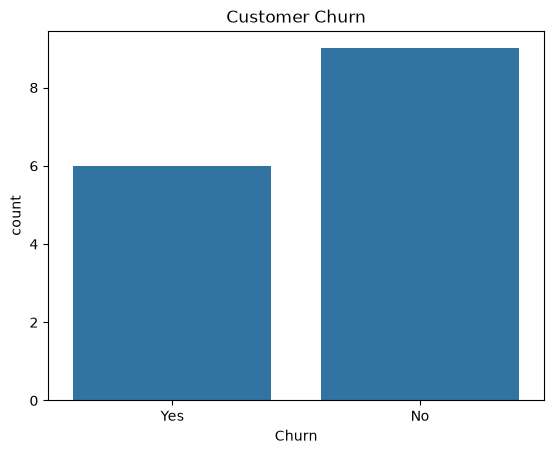

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="Churn", data=data)

plt.title("Customer Churn")
plt.show()

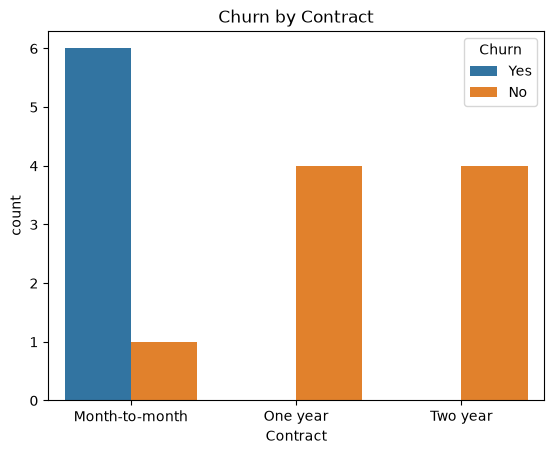

In [21]:
sns.countplot(
    x="Contract",
    hue="Churn",
    data=data
)

plt.title("Churn by Contract")
plt.show()

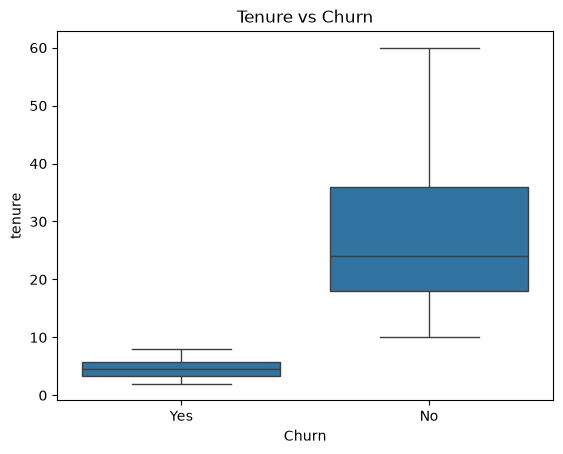

In [22]:
sns.boxplot(
    x="Churn",
    y="tenure",
    data=data
)

plt.title("Tenure vs Churn")
plt.show()

In [23]:
data["Churn"] = data["Churn"].map({
    "Yes": 1,
    "No": 0
})

In [24]:
data = pd.get_dummies(
    data,
    columns=["Contract", "InternetService", "TechSupport"],
    drop_first=True
)

In [25]:
data.head()

,tenure,MonthlyCharges,Churn,Contract_One year,Contract_Two year,InternetService_Fiber,TechSupport_Yes
0,2,80,1,False,False,True,False
1,5,75,1,False,False,False,False
2,10,65,0,False,False,True,True
3,24,50,0,True,False,False,True
4,36,45,0,False,True,False,True


In [26]:
X = data.drop("Churn", axis=1)

y = data["Churn"]

In [27]:
print(X)
print(y)

    tenure  MonthlyCharges  Contract_One year  Contract_Two year  \
0        2              80              False              False   
1        5              75              False              False   
2       10              65              False              False   
3       24              50               True              False   
4       36              45              False               True   
5        3              90              False              False   
6       18              60               True              False   
7       30              40              False               True   
8        6              85              False              False   
9       48              35              False               True   
10      12              70               True              False   
11       4              95              False              False   
12      60              30              False               True   
13       8              88              False   

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [29]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [30]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression()

logistic_model.fit(
    X_train_scaled,
    y_train
)

y_pred_logistic = logistic_model.predict(X_test_scaled)

In [31]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)

In [32]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

In [33]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf, zero_division=0))
print("Recall:", recall_score(y_test, y_pred_rf, zero_division=0))
print("F1 Score:", f1_score(y_test, y_pred_rf, zero_division=0))

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0


In [34]:
import pandas as pd
from sklearn.datasets import load_breast_cancer

dataset = load_breast_cancer()

data = pd.DataFrame(
    dataset.data,
    columns=dataset.feature_names
)

data["target"] = dataset.target

data.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0
